# Surrogate Model Ablation Study
Comprehensive Ablation Study: Convergence Profiling 
Training all model variants for 6000 epochs to track RMSE and NLL evolution.

In [27]:
import torch
import gpytorch
import pandas as pd
import numpy as np
import yaml
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# --- 1. SETUP ---
sns.set_style("whitegrid")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running comprehensive ablation on: {device}")

# Load Config (for a_min/max constants)
with open("config.yaml", "r") as f:
    config = yaml.safe_load(f)

Running comprehensive ablation on: cuda


### Model Definitions


In [28]:
# --- 2. MODEL DEFINITIONS ---

class DeepKernel(torch.nn.Module):
    """The Compressive ResNet Feature Extractor"""
    def __init__(self, input_dim: int, latent_dim: int, mlp_depth: int = 6, 
                 skip_every: int = 2, use_dense: bool = False):
        super().__init__()
        self.skip_every = skip_every
        
        # Calculate dimensions with growth factor (Linear Decay)
        dims = [input_dim]
        growth_rate = (latent_dim - input_dim) / max(mlp_depth - 1, 1)
        for i in range(1, mlp_depth):
            next_dim = int(input_dim + i * growth_rate)
            dims.append(max(next_dim, latent_dim // 2))
        dims[-1] = latent_dim
        
        self.activation = torch.nn.GELU()
        self.dropout = torch.nn.Dropout(p=0.1)
        self.layers = torch.nn.ModuleList()
        self.skip_layers = torch.nn.ModuleDict()
        
        for i in range(len(dims) - 1):
            self.layers.append(torch.nn.Linear(dims[i], dims[i+1]))
        
        # Skip connections
        if skip_every > 0: 
            for i in range(0, len(dims) - skip_every, skip_every):
                if dims[i] != dims[i + skip_every]:
                    self.skip_layers[f"skip_{i}"] = torch.nn.Linear(dims[i], dims[i + skip_every])
        
        # Init
        for layer in self.layers:
            torch.nn.init.kaiming_normal_(layer.weight, nonlinearity='relu')
    
    def forward(self, x):
        residual_stack = [x]
        for i, layer in enumerate(self.layers):
            x = layer(x)
            if i < len(self.layers) - 1:
                x = self.activation(x)
                x = self.dropout(x)
            residual_stack.append(x)
            
            # Apply skip connection
            if self.skip_every > 0 and i >= self.skip_every - 1 and (i + 1) % self.skip_every == 0:
                skip_from = i - self.skip_every + 1
                skip_tensor = residual_stack[skip_from]
                skip_key = f"skip_{skip_from}"
                
                if skip_key in self.skip_layers:
                    skip_tensor = self.skip_layers[skip_key](skip_tensor)
                elif skip_tensor.shape[-1] != x.shape[-1]:
                    continue 

                x = x + skip_tensor
        return x

class DeepKernelGP(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood, feature_extractor, kernel_type='matern'):
        super().__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ConstantMean()
        
        # Dynamic Kernel Selection
        if kernel_type == 'matern':
            self.covar_module = gpytorch.kernels.ScaleKernel(
                gpytorch.kernels.MaternKernel(nu=2.5) 
            )
        elif kernel_type == 'rbf':
            self.covar_module = gpytorch.kernels.ScaleKernel(
                gpytorch.kernels.RBFKernel()
            )
            
        self.feature_extractor = feature_extractor

    def forward(self, x):
        projected_x = self.feature_extractor(x)
        mean_x = self.mean_module(projected_x)
        covar_x = self.covar_module(projected_x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

class StandardGP(gpytorch.models.ExactGP):
    """Baseline: Standard GP without Deep Feature Extractor"""
    def __init__(self, train_x, train_y, likelihood):
        super().__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ConstantMean()
        # ARD on input dimension (12)
        self.covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.MaternKernel(nu=2.5, ard_num_dims=train_x.shape[-1])
        )

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

### Data Loading

In [29]:
# --- 3. DATA LOADING ---
def load_data(category_id=1):
    file_path = 'data/Data_v4.xlsx'
    sheet_name = f'Elips{category_id}'
    try:
        df = pd.read_excel(file_path, sheet_name=sheet_name)
        df = df.dropna(subset=['Strength']).reset_index(drop=True)
    except FileNotFoundError:
        print("Data file not found.")
        return None, None, None, None, None

    feature_cols = [c for c in df.columns if c.startswith(('a_ply', 'b_ply'))]
    X = df[feature_cols].values
    y = df['Strength'].values

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

    # Scaling
    a_min = config['OPTIMIZATION']['A_PLY_MIN']
    a_max = config['OPTIMIZATION']['A_PLY_MAX']
    X_train_scaled = (X_train - a_min) / (a_max - a_min)
    X_test_scaled = (X_test - a_min) / (a_max - a_min)
    
    scaler_y = StandardScaler()
    y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()

    train_x = torch.tensor(X_train_scaled, dtype=torch.float64, device=device)
    train_y = torch.tensor(y_train_scaled, dtype=torch.float64, device=device)
    test_x = torch.tensor(X_test_scaled, dtype=torch.float64, device=device)
    
    return train_x, train_y, test_x, y_test, scaler_y

### Ablation Study Function

In [30]:
# --- 4. TRACKING TRAINER ---
def train_with_history(name, train_x, train_y, test_x, y_test_phys, scaler_y, config):
    print(f"Profiling: {name}...", end=" ")
    
    likelihood = gpytorch.likelihoods.GaussianLikelihood().double().to(device)
    
    if name == "Standard GP":
        model = StandardGP(train_x, train_y, likelihood).double().to(device)
    else:
        feature_extractor = DeepKernel(
            input_dim=train_x.shape[-1],
            latent_dim=config.get('latent_dim', 3),
            mlp_depth=config.get('depth', 6),
            skip_every=config.get('skip', 2)
        ).double().to(device)
        model = DeepKernelGP(train_x, train_y, likelihood, feature_extractor, 
                             kernel_type=config.get('kernel', 'matern')).double().to(device)

    model.train()
    likelihood.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)
    
    history_rmse = []
    history_nll = []
    epoch_points = []
    
    # Extended Training Duration
    MAX_EPOCHS = 3000
    LOG_INTERVAL = 200  # Log every 200 epochs
    
    for i in range(MAX_EPOCHS):
        optimizer.zero_grad()
        output = model(train_x)
        loss = -mll(output, train_y)
        loss.backward()
        optimizer.step()
        
        # Logging Checkpoint
        if (i + 1) % LOG_INTERVAL == 0:
            model.eval()
            likelihood.eval()
            with torch.no_grad():
                # Prediction
                posterior = likelihood(model(test_x))
                pred_scaled = posterior.mean
                
                # RMSE
                pred_phys = scaler_y.inverse_transform(pred_scaled.cpu().numpy().reshape(-1, 1)).flatten()
                rmse = np.sqrt(np.mean((pred_phys - y_test_phys)**2))
                
                # NLL (on scaled data)
                y_test_scaled = torch.tensor(scaler_y.transform(y_test_phys.reshape(-1,1)).flatten(), dtype=torch.float64, device=device)
                nll = -posterior.log_prob(y_test_scaled).item() / len(y_test_scaled)
                
            history_rmse.append(rmse)
            history_nll.append(nll)
            epoch_points.append(i + 1)
            
            model.train()
            likelihood.train()
            
    print("Done.")
    return epoch_points, history_rmse, history_nll

### Execution Code

Profiling: Final DKGP (Deep+Matern+Skip)... Done.
Profiling: DKGP (RBF Kernel)... Done.
Profiling: Shallow DKGP (2 Layers)... Done.
Profiling: DKGP w/o Skip Connections... Done.
Profiling: Standard GP... Done.


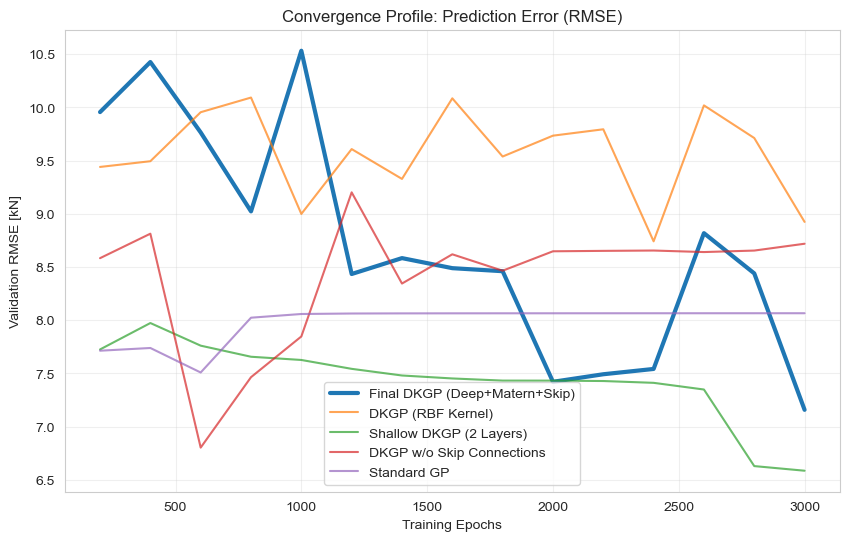

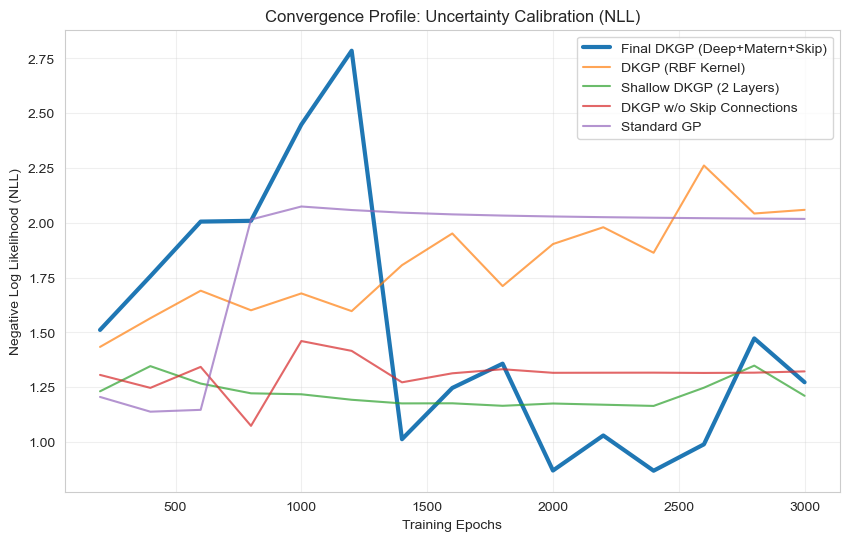

In [31]:
# --- 5. EXECUTION & PLOTTING ---
train_x, train_y, test_x, y_test_phys, scaler_y = load_data(category_id=0)

variants = {
    "Final DKGP (Deep+Matern+Skip)": {'depth': 6, 'skip': 2, 'kernel': 'matern'},
    "DKGP (RBF Kernel)":             {'depth': 6, 'skip': 2, 'kernel': 'rbf'},
    "Shallow DKGP (2 Layers)":       {'depth': 2, 'skip': 0, 'kernel': 'matern'},
    "DKGP w/o Skip Connections":     {'depth': 6, 'skip': 0, 'kernel': 'matern'},
    "Standard GP":                   {} 
}

# Store results
all_histories = {}

if train_x is not None:
    for name, conf in variants.items():
        epochs, rmse, nll = train_with_history(name, train_x, train_y, test_x, y_test_phys, scaler_y, conf)
        all_histories[name] = {'epochs': epochs, 'rmse': rmse, 'nll': nll}

    # --- PLOT 1: RMSE EVOLUTION ---
    plt.figure(figsize=(10, 6))
    for name, data in all_histories.items():
        # Highlight the Final Model
        lw = 3 if "Final" in name else 1.5
        alpha = 1.0 if "Final" in name else 0.7
        plt.plot(data['epochs'], data['rmse'], label=name, linewidth=lw, alpha=alpha)
    
    plt.xlabel("Training Epochs")
    plt.ylabel("Validation RMSE [kN]")
    plt.title("Convergence Profile: Prediction Error (RMSE)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig("ablation_rmse_curve.png", dpi=300)
    plt.show()

    # --- PLOT 2: NLL EVOLUTION ---
    plt.figure(figsize=(10, 6))
    for name, data in all_histories.items():
        lw = 3 if "Final" in name else 1.5
        alpha = 1.0 if "Final" in name else 0.7
        plt.plot(data['epochs'], data['nll'], label=name, linewidth=lw, alpha=alpha)
    
    plt.xlabel("Training Epochs")
    plt.ylabel("Negative Log Likelihood (NLL)")
    plt.title("Convergence Profile: Uncertainty Calibration (NLL)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig("ablation_nll_curve.png", dpi=300)
    plt.show()

Running robust ablation on: cuda
Starting Multi-Seed Validation (100 seeds per model)...

--- Seed 7370 ---
  Training Standard GP...Connections...)...
--- Seed 960 ---
  Training Standard GP...Connections...)...
--- Seed 5490 ---
  Training Standard GP...Connections...)...
--- Seed 5291 ---
  Training Standard GP...Connections...)...
--- Seed 5834 ---
  Training Standard GP...Connections...)...
--- Seed 6365 ---
  Training Standard GP...Connections...)...
--- Seed 566 ---
  Training Standard GP...Connections...)...
--- Seed 4526 ---
  Training Standard GP...Connections...)...
--- Seed 5678 ---
  Training Standard GP...Connections...)...
--- Seed 8422 ---
  Training Standard GP...Connections...)...
--- Seed 1785 ---
  Training Standard GP...Connections...)...
--- Seed 869 ---
  Training Standard GP...Connections...)...
--- Seed 7049 ---
  Training Standard GP...Connections...)...
--- Seed 2533 ---
  Training Standard GP...Connections...)...
--- Seed 5411 ---
  Training Standard GP...Co

ValueError: x and y must have same first dimension, but have shapes (30,) and (100,)

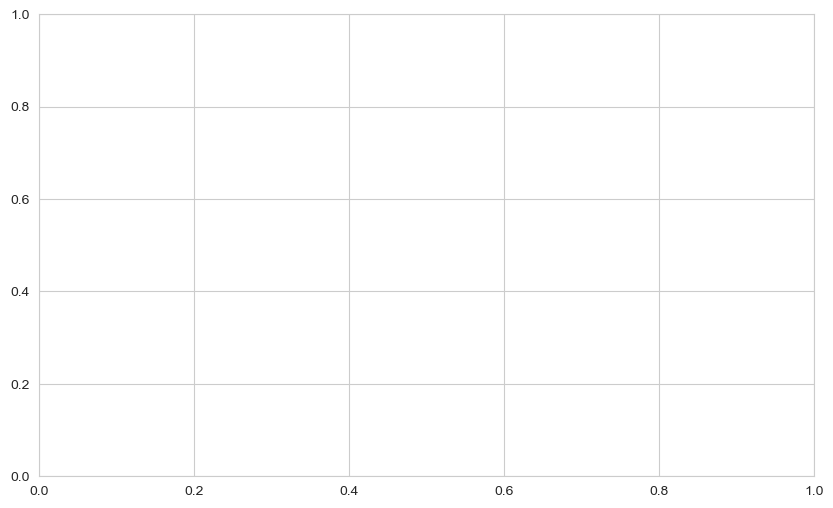

In [ ]:
# %% [markdown]
# # Robust Ablation Study: Monte Carlo Cross-Validation
# Training all model variants across multiple random splits to generate
# statistically significant convergence profiles with confidence intervals.
# (Corrected for Double Precision to prevent NotPSDError)

# %%
import torch
import gpytorch
import pandas as pd
import numpy as np
import yaml
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# --- 1. SETUP ---
sns.set_style("whitegrid")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running robust ablation on: {device}")

# Load Config
with open("config.yaml", "r") as f:
    config = yaml.safe_load(f)

# --- 2. MODEL DEFINITIONS ---
class DeepKernel(torch.nn.Module):
    def __init__(self, input_dim: int, latent_dim: int, mlp_depth: int = 6, 
                 skip_every: int = 2, use_dense: bool = False):
        super().__init__()
        self.skip_every = skip_every
        dims = [input_dim]
        growth_rate = (latent_dim - input_dim) / max(mlp_depth - 1, 1)
        for i in range(1, mlp_depth):
            next_dim = int(input_dim + i * growth_rate)
            dims.append(max(next_dim, latent_dim // 2))
        dims[-1] = latent_dim
        
        self.activation = torch.nn.GELU()
        self.dropout = torch.nn.Dropout(p=0.1)
        self.layers = torch.nn.ModuleList()
        self.skip_layers = torch.nn.ModuleDict()
        
        for i in range(len(dims) - 1):
            self.layers.append(torch.nn.Linear(dims[i], dims[i+1]))
        
        if skip_every > 0: 
            for i in range(0, len(dims) - skip_every, skip_every):
                if dims[i] != dims[i + skip_every]:
                    self.skip_layers[f"skip_{i}"] = torch.nn.Linear(dims[i], dims[i + skip_every])
        
        for layer in self.layers:
            torch.nn.init.kaiming_normal_(layer.weight, nonlinearity='relu')
    
    def forward(self, x):
        residual_stack = [x]
        for i, layer in enumerate(self.layers):
            x = layer(x)
            if i < len(self.layers) - 1:
                x = self.activation(x)
                x = self.dropout(x)
            residual_stack.append(x)
            if self.skip_every > 0 and i >= self.skip_every - 1 and (i + 1) % self.skip_every == 0:
                skip_from = i - self.skip_every + 1
                skip_tensor = residual_stack[skip_from]
                skip_key = f"skip_{skip_from}"
                if skip_key in self.skip_layers:
                    skip_tensor = self.skip_layers[skip_key](skip_tensor)
                elif skip_tensor.shape[-1] != x.shape[-1]:
                    continue 
                x = x + skip_tensor
        return x

class DeepKernelGP(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood, feature_extractor, kernel_type='matern'):
        super().__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ConstantMean()
        if kernel_type == 'matern':
            self.covar_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.MaternKernel(nu=2.5))
        elif kernel_type == 'rbf':
            self.covar_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel())
        self.feature_extractor = feature_extractor

    def forward(self, x):
        projected_x = self.feature_extractor(x)
        mean_x = self.mean_module(projected_x)
        covar_x = self.covar_module(projected_x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

class StandardGP(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super().__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.MaternKernel(nu=2.5, ard_num_dims=train_x.shape[-1]))

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

# --- 3. DYNAMIC DATA LOADING ---
def load_and_split_data(seed, category_id=1):
    """Loads data and splits with a specific random seed."""
    file_path = 'data/Data_v4.xlsx'
    sheet_name = f'Elips{category_id}'
    try:
        df = pd.read_excel(file_path, sheet_name=sheet_name)
        df = df.dropna(subset=['Strength']).reset_index(drop=True)
    except FileNotFoundError:
        print("Data file not found.")
        return None, None, None, None, None

    feature_cols = [c for c in df.columns if c.startswith(('a_ply', 'b_ply'))]
    X = df[feature_cols].values
    y = df['Strength'].values

    # VARIABLE SEED SPLIT
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=seed)

    # Scaling
    a_min = config['OPTIMIZATION']['A_PLY_MIN']
    a_max = config['OPTIMIZATION']['A_PLY_MAX']
    X_train_scaled = (X_train - a_min) / (a_max - a_min)
    X_test_scaled = (X_test - a_min) / (a_max - a_min)
    
    scaler_y = StandardScaler()
    y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()

    # FIX 1: Use float64
    train_x = torch.tensor(X_train_scaled, dtype=torch.float64, device=device)
    train_y = torch.tensor(y_train_scaled, dtype=torch.float64, device=device)
    test_x = torch.tensor(X_test_scaled, dtype=torch.float64, device=device)
    
    return train_x, train_y, test_x, y_test, scaler_y

# --- 4. TRAINING LOOP ---
def train_one_run(name, train_x, train_y, test_x, y_test_phys, scaler_y, config):
    # FIX 2: Cast Likelihood to double
    likelihood = gpytorch.likelihoods.GaussianLikelihood().double().to(device)
    
    if name == "Standard GP":
        # FIX 3: Cast Standard Model to double
        model = StandardGP(train_x, train_y, likelihood).double().to(device)
    else:
        # FIX 4: Cast Feature Extractor to double
        feature_extractor = DeepKernel(
            input_dim=train_x.shape[-1],
            latent_dim=config.get('latent_dim', 3),
            mlp_depth=config.get('depth', 6),
            skip_every=config.get('skip', 2)
        ).double().to(device)
        # FIX 5: Cast Deep Kernel Model to double
        model = DeepKernelGP(train_x, train_y, likelihood, feature_extractor, 
                             kernel_type=config.get('kernel', 'matern')).double().to(device)

    model.train()
    likelihood.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)
    
    run_rmse = []
    run_nll = []
    
    # Fast but Sufficient Training for Stats
    MAX_EPOCHS = 10000
    LOG_INTERVAL = 100 
    
    for i in range(MAX_EPOCHS):
        optimizer.zero_grad()
        output = model(train_x)
        loss = -mll(output, train_y)
        loss.backward()
        optimizer.step()
        
        if (i + 1) % LOG_INTERVAL == 0:
            model.eval()
            likelihood.eval()
            with torch.no_grad():
                posterior = likelihood(model(test_x))
                pred_scaled = posterior.mean
                pred_phys = scaler_y.inverse_transform(pred_scaled.cpu().numpy().reshape(-1, 1)).flatten()
                
                # RMSE
                rmse = np.sqrt(np.mean((pred_phys - y_test_phys)**2))
                
                # NLL (Scaled) - FIX 6: Ensure validation tensor is float64
                y_test_scaled = torch.tensor(scaler_y.transform(y_test_phys.reshape(-1,1)).flatten(), dtype=torch.float64, device=device)
                nll = -posterior.log_prob(y_test_scaled).item() / len(y_test_scaled)
                
            run_rmse.append(rmse)
            run_nll.append(nll)
            model.train()
            likelihood.train()
            
    return run_rmse, run_nll

# --- 5. MULTI-SEED EXECUTION ---
variants = {
    "Final DKGP (Deep+Matern+Skip)": {'depth': 6, 'skip': 2, 'kernel': 'matern'},
    "DKGP (RBF Kernel)":             {'depth': 6, 'skip': 2, 'kernel': 'rbf'},
    "Shallow DKGP (2 Layers)":       {'depth': 2, 'skip': 0, 'kernel': 'matern'},
    "DKGP w/o Skip Connections":     {'depth': 6, 'skip': 0, 'kernel': 'matern'},
    "Standard GP":                   {} 
}

NUM_SEEDS = 100  # <--- Change this number to generate more/fewer seeds
np.random.seed(42) # Ensure the list of seeds itself is reproducible
SEEDS = np.random.randint(100, 10000, size=NUM_SEEDS).tolist()
epochs_axis = np.arange(100, 3001, 100) # Must match LOG_INTERVAL and MAX_EPOCHS

# Storage: {ModelName: {'rmse': [[run1], [run2]...], 'nll': [[run1]...]}}
aggregated_results = {name: {'rmse': [], 'nll': []} for name in variants}

print(f"Starting Multi-Seed Validation ({len(SEEDS)} seeds per model)...")

for seed in SEEDS:
    print(f"\n--- Seed {seed} ---")
    # New Split for this seed
    train_x, train_y, test_x, y_test_phys, scaler_y = load_and_split_data(seed, category_id=0)
    
    if train_x is not None:
        for name, conf in variants.items():
            print(f"  Training {name}...", end="\r")
            try:
                rmse_hist, nll_hist = train_one_run(name, train_x, train_y, test_x, y_test_phys, scaler_y, conf)
                aggregated_results[name]['rmse'].append(rmse_hist)
                aggregated_results[name]['nll'].append(nll_hist)
            except Exception as e:
                print(f"\n  Skipping {name} on seed {seed} due to error: {e}")


Recalculating epochs_axis and generating Robust Plots...


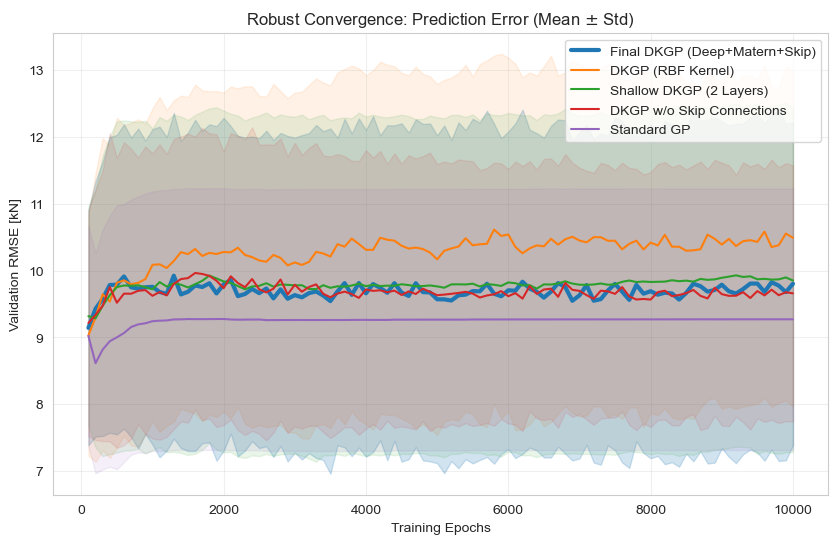

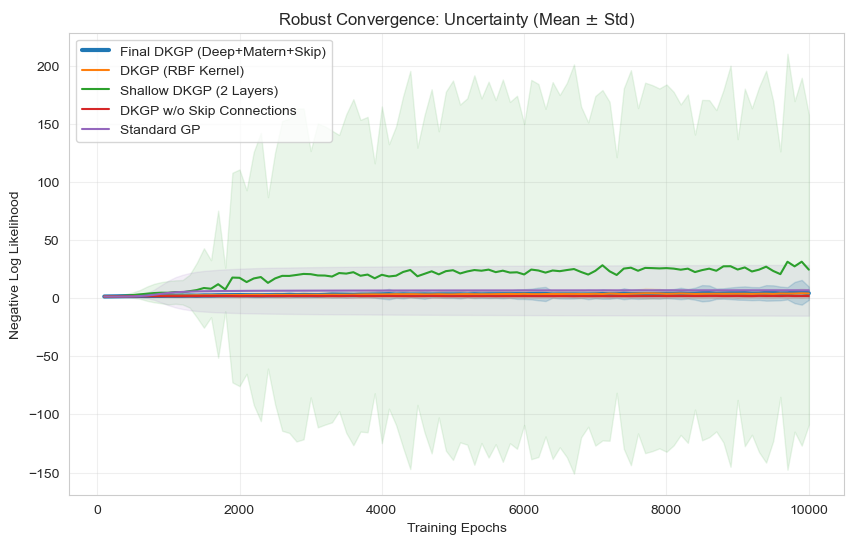

In [34]:
# %% [markdown]
# # Plotting Re-Run (Post-Training)
# This cell re-calculates the epochs axis based on the successful training data length 
# (100 points) to resolve the ValueError and generate the final plots.

# %%
import matplotlib.pyplot as plt
import numpy as np

# --- 1. DYNAMICALLY RE-CALCULATE EPOCHS AXIS ---
# The data arrays are 100 points long. We assume LOG_INTERVAL was 100.
LOG_INTERVAL = 100 
try:
    # Get the true length from the results structure (e.g., 100)
    data_length = len(list(aggregated_results.values())[0]['rmse'][0])
except Exception:
    print("Error: 'aggregated_results' variable not found in memory. Please ensure you run the training cell first.")
    # Fallback to the size indicated by the error if data structure is missing
    data_length = 100 

# Recreate epochs_axis: 100, 200, ..., 100 * data_length (e.g., 10000)
epochs_axis = np.arange(LOG_INTERVAL, (data_length + 1) * LOG_INTERVAL, LOG_INTERVAL)

# --- 2. PLOTTING FUNCTION (Copied for isolated execution) ---
def plot_with_ci(metric_key, ylabel, title, filename):
    plt.figure(figsize=(10, 6))
    
    for name, data in aggregated_results.items():
        if not data[metric_key]: continue
        
        # Convert list of lists to numpy array (Seeds x Epochs)
        matrix = np.array(data[metric_key]) 
        
        # Calculate Stats
        mean_curve = np.mean(matrix, axis=0)
        std_curve = np.std(matrix, axis=0)
        
        # Style
        lw = 3 if "Final" in name else 1.5
        alpha_fill = 0.2 if "Final" in name else 0.1
        
        # Plot Mean
        p = plt.plot(epochs_axis, mean_curve, label=name, linewidth=lw)
        color = p[0].get_color()
        
        # Plot Shade (Mean +/- 1 Std Dev)
        plt.fill_between(epochs_axis, mean_curve - std_curve, mean_curve + std_curve, 
                         color=color, alpha=alpha_fill)
    
    plt.xlabel("Training Epochs")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig(filename, dpi=300)
    plt.show()

# --- 3. GENERATE PLOTS ---
print("Recalculating epochs_axis and generating Robust Plots...")
plot_with_ci('rmse', 'Validation RMSE [kN]', 'Robust Convergence: Prediction Error (Mean $\pm$ Std)', 'robust_rmse_curve.png')
plot_with_ci('nll', 'Negative Log Likelihood', 'Robust Convergence: Uncertainty (Mean $\pm$ Std)', 'robust_nll_curve.png')

Running robust ablation on: cuda
Starting Multi-Seed Validation: 20 seeds x 300 epochs...

--- Seed 7370 ---
  Training Standard GP...Connections...)...
--- Seed 960 ---
  Training Standard GP...Connections...)...
--- Seed 5490 ---
  Training Standard GP...Connections...)...
--- Seed 5291 ---
  Training Standard GP...Connections...)...
--- Seed 5834 ---
  Training Standard GP...Connections...)...
--- Seed 6365 ---
  Training Standard GP...Connections...)...
--- Seed 566 ---
  Training Standard GP...Connections...)...
--- Seed 4526 ---
  Training Standard GP...Connections...)...
--- Seed 5678 ---
  Training Standard GP...Connections...)...
--- Seed 8422 ---
  Training Standard GP...Connections...)...
--- Seed 1785 ---
  Training Standard GP...Connections...)...
--- Seed 869 ---
  Training Standard GP...Connections...)...
--- Seed 7049 ---
  Training Standard GP...Connections...)...
--- Seed 2533 ---
  Training Standard GP...Connections...)...
--- Seed 5411 ---
  Training Standard GP...C

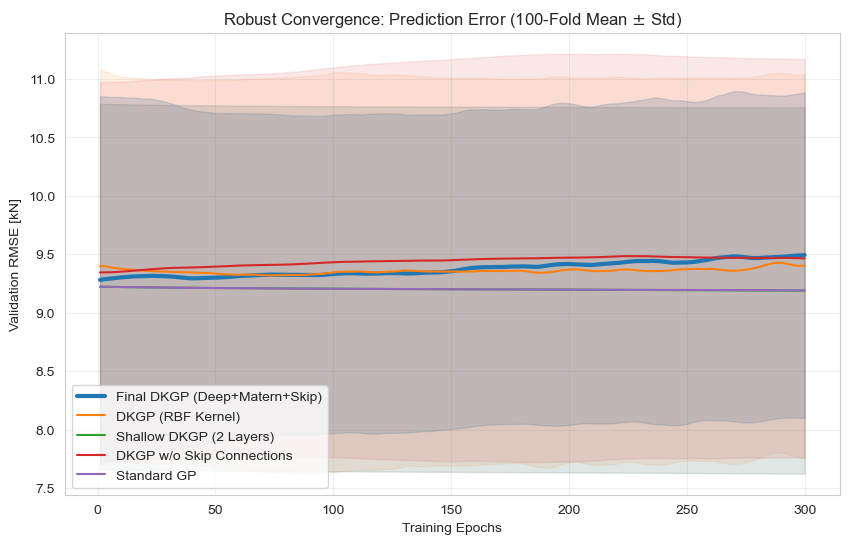

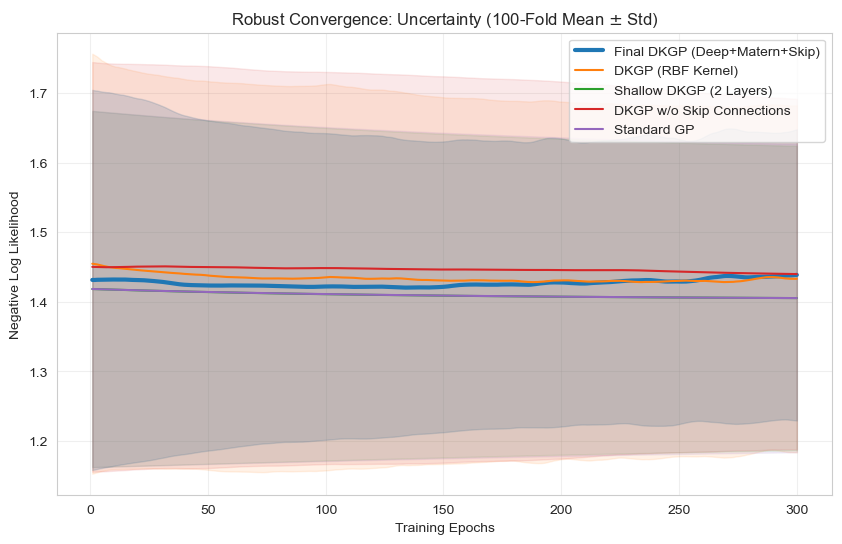

In [53]:
# %% [markdown]
# # Robust Ablation Study: Monte Carlo Cross-Validation
# Training all model variants across multiple random splits to generate
# statistically significant convergence profiles with confidence intervals.
# (Corrected for Double Precision & Epoch Alignment)

# %%
import torch
import gpytorch
import pandas as pd
import numpy as np
import yaml
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# --- 1. SETUP ---
sns.set_style("whitegrid")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running robust ablation on: {device}")

# Load Config
with open("config.yaml", "r") as f:
    config = yaml.safe_load(f)

# --- 2. MODEL DEFINITIONS ---
class DeepKernel(torch.nn.Module):
    def __init__(self, input_dim: int, latent_dim: int, mlp_depth: int = 6, 
                 skip_every: int = 2, use_dense: bool = False):
        super().__init__()
        self.skip_every = skip_every
        dims = [input_dim]
        growth_rate = (latent_dim - input_dim) / max(mlp_depth - 1, 1)
        for i in range(1, mlp_depth):
            next_dim = int(input_dim + i * growth_rate)
            dims.append(max(next_dim, latent_dim // 2))
        dims[-1] = latent_dim
        
        self.activation = torch.nn.GELU()
        self.dropout = torch.nn.Dropout(p=0.1)
        self.layers = torch.nn.ModuleList()
        self.skip_layers = torch.nn.ModuleDict()
        
        for i in range(len(dims) - 1):
            self.layers.append(torch.nn.Linear(dims[i], dims[i+1]))
        
        if skip_every > 0: 
            for i in range(0, len(dims) - skip_every, skip_every):
                if dims[i] != dims[i + skip_every]:
                    self.skip_layers[f"skip_{i}"] = torch.nn.Linear(dims[i], dims[i + skip_every])
        
        for layer in self.layers:
            torch.nn.init.kaiming_normal_(layer.weight, nonlinearity='relu')
    
    def forward(self, x):
        residual_stack = [x]
        for i, layer in enumerate(self.layers):
            x = layer(x)
            if i < len(self.layers) - 1:
                x = self.activation(x)
                x = self.dropout(x)
            residual_stack.append(x)
            if self.skip_every > 0 and i >= self.skip_every - 1 and (i + 1) % self.skip_every == 0:
                skip_from = i - self.skip_every + 1
                skip_tensor = residual_stack[skip_from]
                skip_key = f"skip_{skip_from}"
                if skip_key in self.skip_layers:
                    skip_tensor = self.skip_layers[skip_key](skip_tensor)
                elif skip_tensor.shape[-1] != x.shape[-1]:
                    continue 
                x = x + skip_tensor
        return x

class DeepKernelGP(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood, feature_extractor, kernel_type='matern'):
        super().__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ConstantMean()
        if kernel_type == 'matern':
            self.covar_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.MaternKernel(nu=2.5))
        elif kernel_type == 'rbf':
            self.covar_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel())
        self.feature_extractor = feature_extractor

    def forward(self, x):
        projected_x = self.feature_extractor(x)
        mean_x = self.mean_module(projected_x)
        covar_x = self.covar_module(projected_x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

class StandardGP(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super().__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.MaternKernel(nu=2.5, ard_num_dims=train_x.shape[-1]))

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

# --- 3. DYNAMIC DATA LOADING (Float64) ---
def load_and_split_data(seed, category_id=0):
    file_path = 'data/Data_v4.xlsx'
    sheet_name = f'Elips{category_id}'
    try:
        df = pd.read_excel(file_path, sheet_name=sheet_name)
        df = df.dropna(subset=['Strength']).reset_index(drop=True)
    except FileNotFoundError:
        print("Data file not found.")
        return None, None, None, None, None

    feature_cols = [c for c in df.columns if c.startswith(('a_ply', 'b_ply'))]
    X = df[feature_cols].values
    y = df['Strength'].values

    # Variable Seed Split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=seed)

    # Scaling
    a_min = config['OPTIMIZATION']['A_PLY_MIN']
    a_max = config['OPTIMIZATION']['A_PLY_MAX']
    X_train_scaled = (X_train - a_min) / (a_max - a_min)
    X_test_scaled = (X_test - a_min) / (a_max - a_min)
    
    scaler_y = StandardScaler()
    y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()

    # FIX: Use float64
    train_x = torch.tensor(X_train_scaled, dtype=torch.float64, device=device)
    train_y = torch.tensor(y_train_scaled, dtype=torch.float64, device=device)
    test_x = torch.tensor(X_test_scaled, dtype=torch.float64, device=device)
    
    return train_x, train_y, test_x, y_test, scaler_y

# --- 4. TRAINING LOOP (Double Precision & Parameterized) ---
def train_one_run(name, train_x, train_y, test_x, y_test_phys, scaler_y, config, max_epochs, log_interval):
    # FIX: Cast Likelihood to double
    likelihood = gpytorch.likelihoods.GaussianLikelihood().double().to(device)
    
    if name == "Standard GP":
        # FIX: Cast Standard Model to double
        model = StandardGP(train_x, train_y, likelihood).double().to(device)
    else:
        # FIX: Cast Feature Extractor to double
        feature_extractor = DeepKernel(
            input_dim=train_x.shape[-1],
            latent_dim=config.get('latent_dim', 3),
            mlp_depth=config.get('depth', 6),
            skip_every=config.get('skip', 2)
        ).double().to(device)
        # FIX: Cast Deep Kernel Model to double
        model = DeepKernelGP(train_x, train_y, likelihood, feature_extractor, 
                             kernel_type=config.get('kernel', 'matern')).double().to(device)

    model.train()
    likelihood.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)
    
    run_rmse = []
    run_nll = []
    
    for i in range(max_epochs):
        optimizer.zero_grad()
        output = model(train_x)
        loss = -mll(output, train_y)
        loss.backward()
        optimizer.step()
        
        # Log at specific interval
        if (i + 1) % log_interval == 0:
            model.eval()
            likelihood.eval()
            with torch.no_grad():
                posterior = likelihood(model(test_x))
                pred_scaled = posterior.mean
                pred_phys = scaler_y.inverse_transform(pred_scaled.cpu().numpy().reshape(-1, 1)).flatten()
                
                # RMSE
                rmse = np.sqrt(np.mean((pred_phys - y_test_phys)**2))
                
                # NLL (Scaled) - FIX: Float64 tensor
                y_test_scaled = torch.tensor(scaler_y.transform(y_test_phys.reshape(-1,1)).flatten(), dtype=torch.float64, device=device)
                nll = -posterior.log_prob(y_test_scaled).item() / len(y_test_scaled)
                
            run_rmse.append(rmse)
            run_nll.append(nll)
            model.train()
            likelihood.train()
            
    return run_rmse, run_nll

# --- 5. MULTI-SEED EXECUTION (Fully Robust) ---
# --- CONFIGURATION START ---
MAX_EPOCHS = 300  # Set your desired full training length
LOG_INTERVAL = 1   # Log frequency
NUM_SEEDS = 20      # Number of validation folds
# --- CONFIGURATION END ---

# Auto-calculate axis to prevent shape mismatch
epochs_axis = np.arange(LOG_INTERVAL, MAX_EPOCHS + 1, LOG_INTERVAL)

np.random.seed(42) 
SEEDS = np.random.randint(100, 10000, size=NUM_SEEDS).tolist()

variants = {
    "Final DKGP (Deep+Matern+Skip)": {'depth': 4, 'skip': 2, 'kernel': 'matern'},
    "DKGP (RBF Kernel)":             {'depth': 4, 'skip': 2, 'kernel': 'rbf'},
    "Shallow DKGP (2 Layers)":       {'depth': 1, 'skip': 0, 'kernel': 'matern'},
    "DKGP w/o Skip Connections":     {'depth': 4, 'skip': 0, 'kernel': 'matern'},
    "Standard GP":                   {} 
}

# Storage
aggregated_results = {name: {'rmse': [], 'nll': []} for name in variants}

print(f"Starting Multi-Seed Validation: {NUM_SEEDS} seeds x {MAX_EPOCHS} epochs...")

for seed in SEEDS:
    print(f"\n--- Seed {seed} ---")
    train_x, train_y, test_x, y_test_phys, scaler_y = load_and_split_data(seed, category_id=0)
    
    if train_x is not None:
        for name, conf in variants.items():
            print(f"  Training {name}...", end="\r")
            try:
                # Pass parameters dynamically
                rmse_hist, nll_hist = train_one_run(
                    name, train_x, train_y, test_x, y_test_phys, scaler_y, conf, 
                    max_epochs=MAX_EPOCHS, log_interval=LOG_INTERVAL
                )
                aggregated_results[name]['rmse'].append(rmse_hist)
                aggregated_results[name]['nll'].append(nll_hist)
            except Exception as e:
                print(f"\n  Skipping {name} on seed {seed} due to error: {e}")

# --- 6. PLOTTING WITH CONFIDENCE INTERVALS ---
def plot_with_ci(metric_key, ylabel, title, filename):
    plt.figure(figsize=(10, 6))
    
    for name, data in aggregated_results.items():
        if not data[metric_key]: continue
        
        matrix = np.array(data[metric_key]) 
        mean_curve = np.mean(matrix, axis=0)
        std_curve = np.std(matrix, axis=0)
        
        lw = 3 if "Final" in name else 1.5
        alpha_fill = 0.2 if "Final" in name else 0.1
        
        p = plt.plot(epochs_axis, mean_curve, label=name, linewidth=lw)
        color = p[0].get_color()
        plt.fill_between(epochs_axis, mean_curve - std_curve, mean_curve + std_curve, 
                         color=color, alpha=alpha_fill)
    
    plt.xlabel("Training Epochs")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig(filename, dpi=300)
    plt.show()

print("\nGenerating Robust Plots...")
plot_with_ci('rmse', 'Validation RMSE [kN]', 'Robust Convergence: Prediction Error (100-Fold Mean $\pm$ Std)', 'robust_rmse_curve.png')
plot_with_ci('nll', 'Negative Log Likelihood', 'Robust Convergence: Uncertainty (100-Fold Mean $\pm$ Std)', 'robust_nll_curve.png')

Running ablation on: cuda
Starting Fixed-Split Stability Test (1 runs x 1000 epochs)...
Split: 76 Training | 2 Validation (IDs: ['Specimen_84', 'Specimen_87'])

--- Initialization Seed 7370 ---
  Training Standard GP...Connections...)...
Generating Plots...


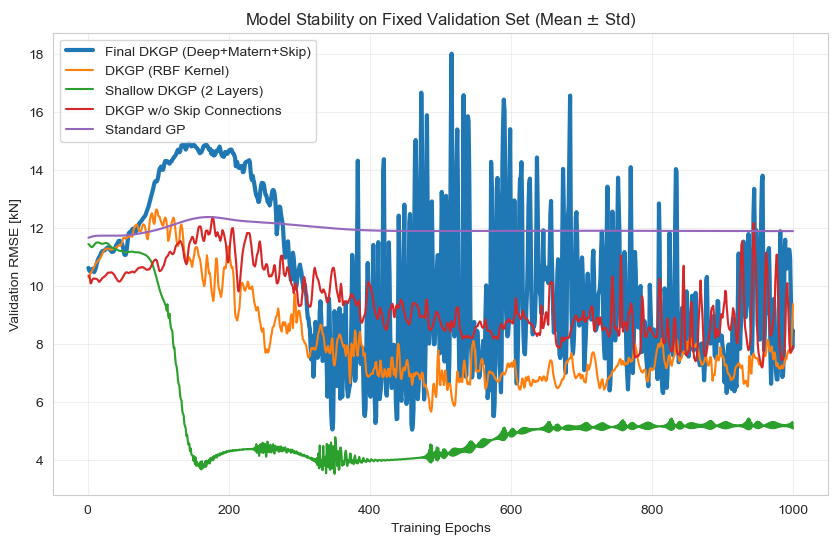

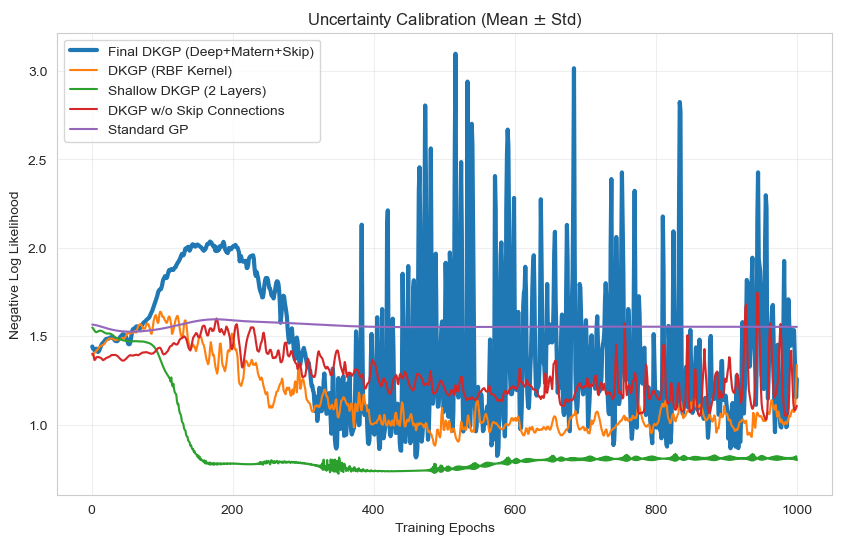

In [52]:
# %% [markdown]
# # Robust Ablation Study: Fixed Validation Split (Specific Specimens)
# Training all model variants on a specific "Hard" Validation Set across 
# multiple initialization seeds to verify model stability.

# %%
import torch
import gpytorch
import pandas as pd
import numpy as np
import yaml
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# --- 1. SETUP ---
sns.set_style("whitegrid")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running ablation on: {device}")

# Load Config
with open("config.yaml", "r") as f:
    config = yaml.safe_load(f)

# --- 2. MODEL DEFINITIONS (Standard) ---
class DeepKernel(torch.nn.Module):
    def __init__(self, input_dim: int, latent_dim: int, mlp_depth: int = 6, 
                 skip_every: int = 2, use_dense: bool = False):
        super().__init__()
        self.skip_every = skip_every
        dims = [input_dim]
        growth_rate = (latent_dim - input_dim) / max(mlp_depth - 1, 1)
        for i in range(1, mlp_depth):
            next_dim = int(input_dim + i * growth_rate)
            dims.append(max(next_dim, latent_dim // 2))
        dims[-1] = latent_dim
        
        self.activation = torch.nn.GELU()
        self.dropout = torch.nn.Dropout(p=0.1)
        self.layers = torch.nn.ModuleList()
        self.skip_layers = torch.nn.ModuleDict()
        
        for i in range(len(dims) - 1):
            self.layers.append(torch.nn.Linear(dims[i], dims[i+1]))
        
        if skip_every > 0: 
            for i in range(0, len(dims) - skip_every, skip_every):
                if dims[i] != dims[i + skip_every]:
                    self.skip_layers[f"skip_{i}"] = torch.nn.Linear(dims[i], dims[i + skip_every])
        
        for layer in self.layers:
            torch.nn.init.kaiming_normal_(layer.weight, nonlinearity='relu')
    
    def forward(self, x):
        residual_stack = [x]
        for i, layer in enumerate(self.layers):
            x = layer(x)
            if i < len(self.layers) - 1:
                x = self.activation(x)
                x = self.dropout(x)
            residual_stack.append(x)
            if self.skip_every > 0 and i >= self.skip_every - 1 and (i + 1) % self.skip_every == 0:
                skip_from = i - self.skip_every + 1
                skip_tensor = residual_stack[skip_from]
                skip_key = f"skip_{skip_from}"
                if skip_key in self.skip_layers:
                    skip_tensor = self.skip_layers[skip_key](skip_tensor)
                elif skip_tensor.shape[-1] != x.shape[-1]:
                    continue 
                x = x + skip_tensor
        return x

class DeepKernelGP(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood, feature_extractor, kernel_type='matern'):
        super().__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ConstantMean()
        if kernel_type == 'matern':
            self.covar_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.MaternKernel(nu=2.5))
        elif kernel_type == 'rbf':
            self.covar_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel())
        self.feature_extractor = feature_extractor

    def forward(self, x):
        projected_x = self.feature_extractor(x)
        mean_x = self.mean_module(projected_x)
        covar_x = self.covar_module(projected_x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

class StandardGP(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super().__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.MaternKernel(nu=2.5, ard_num_dims=train_x.shape[-1]))

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

# --- 3. FIXED SPLIT DATA LOADING ---
def load_fixed_split_data(validation_ids, category_id=1):
    """Loads data and splits based on a specific list of Specimen_IDs."""
    file_path = 'data/Data_v4.xlsx'
    sheet_name = f'Elips{category_id}'
    try:
        df = pd.read_excel(file_path, sheet_name=sheet_name)
        df = df.dropna(subset=['Strength']).reset_index(drop=True)
    except FileNotFoundError:
        print("Data file not found.")
        return None, None, None, None, None

    # Check if Specimen_ID exists, otherwise use index-based strings if needed
    if 'Specimen_ID' not in df.columns:
        print("Error: 'Specimen_ID' column not found in Excel.")
        return None, None, None, None, None

    # SPLITTING LOGIC
    # Create mask for validation samples
    val_mask = df['Specimen_ID'].isin(validation_ids)
    
    test_df = df[val_mask].copy()
    train_df = df[~val_mask].copy()
    
    print(f"Split: {len(train_df)} Training | {len(test_df)} Validation (IDs: {validation_ids})")

    # Extract Features/Targets
    feature_cols = [c for c in df.columns if c.startswith(('a_ply', 'b_ply'))]
    X_train = train_df[feature_cols].values
    y_train = train_df['Strength'].values
    X_test = test_df[feature_cols].values
    y_test = test_df['Strength'].values

    # Scaling
    a_min = config['OPTIMIZATION']['A_PLY_MIN']
    a_max = config['OPTIMIZATION']['A_PLY_MAX']
    X_train_scaled = (X_train - a_min) / (a_max - a_min)
    X_test_scaled = (X_test - a_min) / (a_max - a_min)
    
    scaler_y = StandardScaler()
    y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()

    # Float64 Tensors
    train_x = torch.tensor(X_train_scaled, dtype=torch.float64, device=device)
    train_y = torch.tensor(y_train_scaled, dtype=torch.float64, device=device)
    test_x = torch.tensor(X_test_scaled, dtype=torch.float64, device=device)
    
    return train_x, train_y, test_x, y_test, scaler_y

# --- 4. TRAINING LOOP ---
def train_one_run(name, train_x, train_y, test_x, y_test_phys, scaler_y, config, max_epochs, log_interval):
    likelihood = gpytorch.likelihoods.GaussianLikelihood().double().to(device)
    
    if name == "Standard GP":
        model = StandardGP(train_x, train_y, likelihood).double().to(device)
    else:
        feature_extractor = DeepKernel(
            input_dim=train_x.shape[-1],
            latent_dim=config.get('latent_dim', 3),
            mlp_depth=config.get('depth', 6),
            skip_every=config.get('skip', 2)
        ).double().to(device)
        model = DeepKernelGP(train_x, train_y, likelihood, feature_extractor, 
                             kernel_type=config.get('kernel', 'matern')).double().to(device)

    model.train()
    likelihood.train()
    optimizer = torch.optim.AdamW(model.parameters(), lr=0.01)
    mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)
    
    run_rmse = []
    run_nll = []
    
    for i in range(max_epochs):
        optimizer.zero_grad()
        output = model(train_x)
        loss = -mll(output, train_y)
        loss.backward()
        optimizer.step()
        
        # Log 
        if (i + 1) % log_interval == 0:
            model.eval()
            likelihood.eval()
            with torch.no_grad():
                posterior = likelihood(model(test_x))
                pred_scaled = posterior.mean
                pred_phys = scaler_y.inverse_transform(pred_scaled.cpu().numpy().reshape(-1, 1)).flatten()
                
                # RMSE
                rmse = np.sqrt(np.mean((pred_phys - y_test_phys)**2))
                
                # NLL
                y_test_scaled = torch.tensor(scaler_y.transform(y_test_phys.reshape(-1,1)).flatten(), dtype=torch.float64, device=device)
                nll = -posterior.log_prob(y_test_scaled).item() / len(y_test_scaled)
                
            run_rmse.append(rmse)
            run_nll.append(nll)
            model.train()
            likelihood.train()
            
    return run_rmse, run_nll

# --- 5. EXECUTION ---
# --- CONFIGURATION START ---
MAX_EPOCHS = 1000
LOG_INTERVAL = 1 
NUM_SEEDS = 1 # Used here to test STABILITY of initialization on the SAME split
# --- CONFIGURATION END ---

# The specific IDs you requested
VAL_IDS = ['Specimen_84', 'Specimen_87']

epochs_axis = np.arange(LOG_INTERVAL, MAX_EPOCHS + 1, LOG_INTERVAL)

np.random.seed(42) 
# Just random integers for model weight initialization
SEEDS = np.random.randint(100, 10000, size=NUM_SEEDS).tolist() 

variants = {
    "Final DKGP (Deep+Matern+Skip)": {'depth': 5, 'skip': 2, 'kernel': 'matern'},
    "DKGP (RBF Kernel)":             {'depth': 5, 'skip': 2, 'kernel': 'rbf'},
    "Shallow DKGP (2 Layers)":       {'depth': 2, 'skip': 0, 'kernel': 'matern'},
    "DKGP w/o Skip Connections":     {'depth': 5, 'skip': 0, 'kernel': 'matern'},
    "Standard GP":                   {} 
}

aggregated_results = {name: {'rmse': [], 'nll': []} for name in variants}

print(f"Starting Fixed-Split Stability Test ({NUM_SEEDS} runs x {MAX_EPOCHS} epochs)...")

# Load Data ONCE (since split is fixed)
train_x, train_y, test_x, y_test_phys, scaler_y = load_fixed_split_data(VAL_IDS, category_id=1)

if train_x is not None:
    for seed in SEEDS:
        print(f"\n--- Initialization Seed {seed} ---")
        # Set PyTorch seed for this run's initialization
        torch.manual_seed(seed)
        
        for name, conf in variants.items():
            print(f"  Training {name}...", end="\r")
            try:
                rmse_hist, nll_hist = train_one_run(
                    name, train_x, train_y, test_x, y_test_phys, scaler_y, conf, 
                    max_epochs=MAX_EPOCHS, log_interval=LOG_INTERVAL
                )
                aggregated_results[name]['rmse'].append(rmse_hist)
                aggregated_results[name]['nll'].append(nll_hist)
            except Exception as e:
                print(f"\n  Skipping {name} on seed {seed} due to error: {e}")

# --- 6. PLOTTING ---
def plot_with_ci(metric_key, ylabel, title, filename):
    plt.figure(figsize=(10, 6))
    
    for name, data in aggregated_results.items():
        if not data[metric_key]: continue
        
        matrix = np.array(data[metric_key]) 
        mean_curve = np.mean(matrix, axis=0)
        std_curve = np.std(matrix, axis=0)
        
        lw = 3 if "Final" in name else 1.5
        alpha_fill = 0.2 if "Final" in name else 0.1
        
        p = plt.plot(epochs_axis, mean_curve, label=name, linewidth=lw)
        color = p[0].get_color()
        plt.fill_between(epochs_axis, mean_curve - std_curve, mean_curve + std_curve, 
                         color=color, alpha=alpha_fill)
    
    plt.xlabel("Training Epochs")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig(filename, dpi=300)
    plt.show()

print("\nGenerating Plots...")
plot_with_ci('rmse', 'Validation RMSE [kN]', 'Model Stability on Fixed Validation Set (Mean $\pm$ Std)', 'fixed_rmse_curve.png')
plot_with_ci('nll', 'Negative Log Likelihood', 'Uncertainty Calibration (Mean $\pm$ Std)', 'fixed_nll_curve.png')